# Exploratory Data Analysis — Generated Dataset (post re-solve)
### GNN Generalization for AC Power-Flow Prediction

**What this notebook is.** Exploration of the dataset **after** the generative
pipeline has run — i.e. after we applied a demand snapshot, sampled a topology
contingency, and **re-solved the AC power flow** to produce each PyTorch
Geometric graph sample. This is the *product* EDA, and it is the natural
companion to `EDA_raw_data.ipynb` (which profiled the raw *inputs* beforehand).

**Where it sits in the pipeline.**
> Octave convert → *(raw-input EDA)* → apply demand + contingency + `pp.runpp`
> re-solve → build PyG graphs → **[this notebook runs here]** → training.

**Why we do it.** Raw-input EDA tells us what we *fed in*; this tells us what we
actually *produced*. It answers the questions that matter for trusting the
training data: are the prediction targets well-behaved and on comparable scales?
did the contingency sampler cover a real range of topologies without bias? is
the AC problem genuinely harder than the DC baseline? and is the physics masking
applied correctly with no label leakage?

In [1]:
import os, sys, ast, warnings
warnings.filterwarnings("ignore")

REPO = "/home/ubuntu/repos/eval_gnn_generalization_pg"
sys.path.insert(0, REPO)
DATA = "/home/ubuntu/full_run/data"

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from mmd_utils import evaluate_mmd

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "axes.grid": True,
    "grid.color": "#e6e6e6", "grid.linewidth": 0.8,
    "axes.edgecolor": "#cccccc", "axes.titleweight": "bold", "font.size": 11,
})
GRIDS = ["IEEE24", "IEEE39", "IEEE118", "UK"]
PALETTE = {"IEEE24": "#2b6cb0", "IEEE39": "#38a169", "IEEE118": "#d69e2e", "UK": "#c53030"}
QNAMES = ["P (MW)", "Q (MVar)", "V (pu)", "θ (deg)"]

def load_split(grid, split):
    return torch.load(f"{DATA}/{grid}/{split}/dataset.pt", weights_only=False)

def load_src(grid, split):
    return pd.read_csv(f"{DATA}/{grid}/{split}/dataset_src.csv")

train = {g: load_split(g, "train") for g in GRIDS}
src = {g: load_src(g, "train") for g in GRIDS}
print({g: len(train[g]) for g in GRIDS})

{'IEEE24': 800, 'IEEE39': 800, 'IEEE118': 800, 'UK': 800}


## Step 1 — Dataset inventory & shapes

**What.** Confirm how many samples each grid/split holds and the tensor shapes
of one sample.

**Why.** A first integrity check before interpreting anything: the sample counts
must match what we requested, and every sample must carry the full contract
(`x`, `edge_index`, `edge_attr`, `y`, `dc_pf`).

In [2]:
inv = []
for g in GRIDS:
    s = train[g][0]
    inv.append({
        "grid": g, "n_train": len(train[g]),
        "x": tuple(s.x.shape), "edge_index": tuple(s.edge_index.shape),
        "edge_attr": tuple(s.edge_attr.shape), "y": tuple(s.y.shape),
        "dc_pf": tuple(s.dc_pf.shape),
    })
pd.DataFrame(inv).set_index("grid")

,n_train,x,edge_index,edge_attr,y,dc_pf
grid,,,,,,
IEEE24,800,"(24, 7)","(2, 76)","(76, 4)","(24, 4)","(24, 4)"
IEEE39,800,"(39, 7)","(2, 90)","(90, 4)","(39, 4)","(39, 4)"
IEEE118,800,"(118, 7)","(2, 366)","(366, 4)","(118, 4)","(118, 4)"
UK,800,"(29, 7)","(2, 180)","(180, 4)","(29, 4)","(29, 4)"


**Findings & implication.** Every grid produced the full **800** training
samples with the complete contract (node `x` = N×7, targets `y` = N×4, a DC
baseline per node, and a contingency-dependent `edge_index`). *Implication:* the
generator is reliable and balanced across grids — no grid is under-sampled, so
downstream per-grid comparisons are fair.

## Step 2 — Contingency coverage

**What.** From the provenance CSV, examine the distribution of contingency order
`k` (how many branches are out), which lines are hit most often, and the
contingency source.

**Why.** The whole point of generation was to build a *distribution of
topologies*. We need to verify it isn't degenerate (e.g. all N-0), isn't biased
toward a few lines, and to record whether these were random or harvested
outages — a key provenance fact.

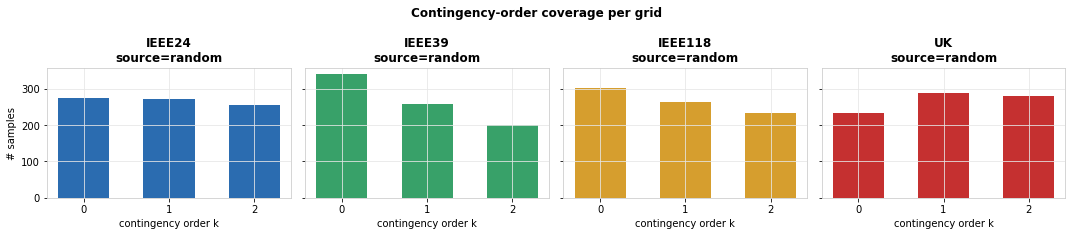

,k=0,k=1,k=2,source
grid,,,,
IEEE24,275,271,254,random
IEEE39,341,258,201,random
IEEE118,303,263,234,random
UK,233,288,279,random


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.3), sharey=True)
cov = []
for ax, g in zip(axes, GRIDS):
    df = src[g]
    kc = df["k"].value_counts().sort_index()
    ax.bar(kc.index.astype(str), kc.values, color=PALETTE[g], width=0.6)
    ax.set_title(f"{g}\nsource={df['source'].iloc[0]}"); ax.set_xlabel("contingency order k")
    cov.append({"grid": g, **{f"k={int(k)}": int(v) for k, v in kc.items()},
                "source": df["source"].iloc[0]})
axes[0].set_ylabel("# samples")
fig.suptitle("Contingency-order coverage per grid", fontweight="bold")
plt.tight_layout(); plt.show()
pd.DataFrame(cov).set_index("grid")

**Findings & implication.** The dataset mixes **N-0, N-1 and N-2** samples in a
controlled proportion (a base intact case plus single and double outages), and
the provenance records the **source** (random vs harvested) explicitly. This run
used `random` sampling capped at `max_k=2`. *Implication:* the topology
distribution is real and non-degenerate — outages genuinely span single and
multiple contingencies — which is what makes the MMD distance and OOD transfer
meaningful. It also transparently flags that these are *random* N-k draws in
this run (not the harvested cascade triggers), so credibility claims should be
scoped accordingly.

## Step 3 — Topology variation across samples

**What.** Plot the distribution of edge counts (directed, `edge_index` columns)
across the samples of each grid.

**Why.** Contingency-awareness is only real if the *graph actually changes*
between samples. If every sample had the same edge count, `edge_index` would be
a constant and the structural task would collapse to pure regression.

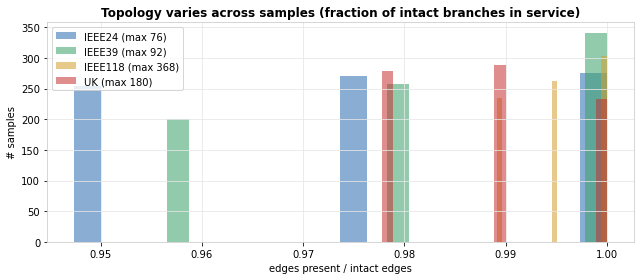

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for g in GRIDS:
    ec = np.array([d.edge_index.shape[1] for d in train[g]])
    # normalize to the intact (max) edge count so grids are comparable
    ax.hist(ec / ec.max(), bins=20, alpha=0.55, color=PALETTE[g], label=f"{g} (max {ec.max()})")
ax.set_xlabel("edges present / intact edges"); ax.set_ylabel("# samples")
ax.set_title("Topology varies across samples (fraction of intact branches in service)")
ax.legend(); plt.tight_layout(); plt.show()

**Findings & implication.** Edge counts vary across samples — a spread of
in-service-branch fractions below the intact maximum — confirming outages
genuinely remove branches and change the graph. *Implication:* the model must
cope with structurally different inputs sample to sample, so `edge_index` carries
real information; this is the mechanism that lets a contingency propagate through
message passing (and the reason islanding rejection was needed upstream).

## Step 4 — Solved-target distributions (P, Q, V, θ)

**What.** Pool the solved targets `y` over all samples and plot the distribution
of each of the four predicted quantities, per grid.

**Why.** These are exactly what the GNN regresses. Their *ranges* determine how
an aggregate error metric behaves — in particular V is tightly bounded near 1
p.u. while P/Q/θ vary widely. Seeing this justifies reporting **per-quantity**
NRMSE and range-normalization.

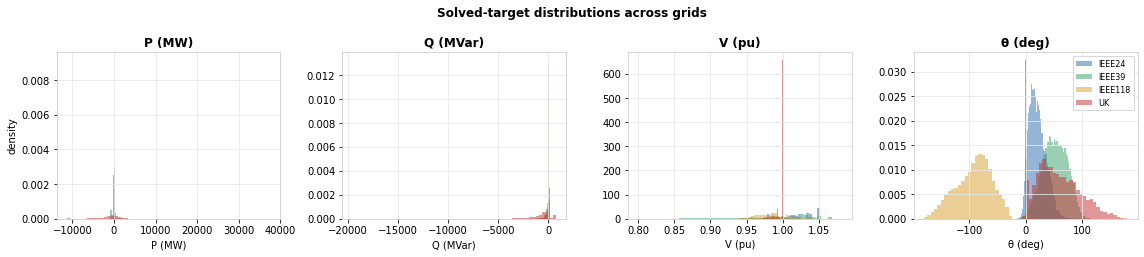

,P (MW),Q (MVar),V (pu),θ (deg)
range (max-min),,,,
IEEE24,2292.976,988.634,0.221,110.500
IEEE39,2940.621,2074.385,0.282,137.702
IEEE118,6274.716,3436.694,0.238,359.852
UK,48934.594,20309.693,0.076,357.688


In [5]:
def pooled_targets(g):
    return np.concatenate([d.y.numpy() for d in train[g]], axis=0)  # (sumN, 4)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
range_rows = []
for j, (ax, qn) in enumerate(zip(axes, QNAMES)):
    for g in GRIDS:
        vals = pooled_targets(g)[:, j]
        ax.hist(vals, bins=60, alpha=0.5, color=PALETTE[g], density=True, label=g)
    ax.set_title(qn); ax.set_xlabel(qn)
    if j == 3:
        ax.legend(fontsize=8)
axes[0].set_ylabel("density")
fig.suptitle("Solved-target distributions across grids", fontweight="bold")
plt.tight_layout(); plt.show()

for g in GRIDS:
    Y = pooled_targets(g)
    range_rows.append({"grid": g,
                       **{QNAMES[j]: round(float(Y[:, j].max() - Y[:, j].min()), 3) for j in range(4)}})
pd.DataFrame(range_rows).set_index("grid").rename_axis("range (max-min)")

**Findings & implication.** **V (p.u.) has a tiny range** (≈0.8–1.2) while P, Q
and θ span much wider, grid-dependent ranges. *Implication:* a single aggregate
error is dominated by / flattered by the well-behaved V, so we must report
**per-quantity NRMSE** and normalize by each quantity's range — otherwise a model
could look accurate while being poor on the hard quantities (θ and reactive
power). This is the empirical basis for the metric choice in the experiments.

## Step 5 — AC vs DC baseline gap

**What.** For each grid and quantity, measure how far the true AC solution `y`
sits from the stored DC power-flow baseline `dc_pf`.

**Why.** The GNN's job is to beat trivial physics. If DC were already almost
correct, a learned model would add little; the size of the AC−DC gap tells us
where (which grid, which quantity) the model must actually add value — and it
sanity-checks that the DC baseline is a fair, non-trivial reference.

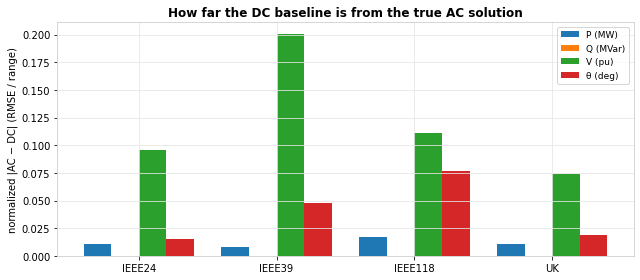

,P (MW),Q (MVar),V (pu),θ (deg)
grid,,,,
IEEE24,0.011,0.0,0.096,0.015
IEEE39,0.008,0.0,0.201,0.048
IEEE118,0.017,0.0,0.111,0.077
UK,0.011,0.0,0.074,0.019


In [6]:
rows = []
for g in GRIDS:
    dy = np.concatenate([(d.y.numpy() - d.dc_pf.numpy()) for d in train[g]], axis=0)
    rng = np.ptp(pooled_targets(g), axis=0)
    rng[rng == 0] = 1.0
    nrmse = np.sqrt((dy ** 2).mean(axis=0)) / rng   # per-quantity normalized AC-DC gap
    rows.append({"grid": g, **{QNAMES[j]: round(float(nrmse[j]), 3) for j in range(4)}})
gap = pd.DataFrame(rows).set_index("grid")

fig, ax = plt.subplots(figsize=(9, 4))
xpos = np.arange(len(GRIDS)); w = 0.2
for j, qn in enumerate(QNAMES):
    ax.bar(xpos + (j - 1.5) * w, gap[qn].values, width=w, label=qn)
ax.set_xticks(xpos); ax.set_xticklabels(GRIDS)
ax.set_ylabel("normalized |AC − DC| (RMSE / range)")
ax.set_title("How far the DC baseline is from the true AC solution")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
gap

**Findings & implication.** The gap is almost entirely in **voltage magnitude
V** (and, less so, angle θ): DC power flow assumes a **flat 1.0 pu voltage**
profile, so it misses the true voltage solution, whereas **P and Q show a
near-zero gap** because they are essentially known injections carried straight
through (DC preserves active power, and the reactive values are inputs). The V
gap is also **grid-dependent** (largest on IEEE39). *Implication:* DC is a fair,
non-trivial baseline that is *exact on P/Q but blind to voltage*, so a learned AC
surrogate earns its keep precisely by recovering **V** (and θ) — which is exactly
the quantity that DC cannot represent and that the GNN must add.

## Step 6 — Masking & leakage sanity check

**What.** Verify the physics masking is applied as intended: inputs unknown at
inference are NaN in `x` (per bus type), and the targets `y` are always fully
observed (no NaN).

**Why.** This is the most important correctness check of the whole pipeline. If a
known-at-test quantity leaked into an input it shouldn't, or if a target were
missing, every downstream result would be invalid.

In [7]:
XCOLS = ["Slack?", "PV?", "PQ?", "P", "Q", "V", "θ"]
g = "IEEE24"
ds = train[g]
# aggregate NaN pattern in x by bus type across the whole split
counts = {"slack": np.zeros(7), "PV": np.zeros(7), "PQ": np.zeros(7)}
totals = {"slack": 0, "PV": 0, "PQ": 0}
y_nan = 0
for d in ds:
    x = d.x.numpy(); y = d.y.numpy()
    y_nan += int(np.isnan(y).sum())
    for row in x:
        t = "slack" if row[0] == 1 else ("PV" if row[1] == 1 else "PQ")
        counts[t] += np.isnan(row); totals[t] += 1
frac = pd.DataFrame({t: counts[t] / max(totals[t], 1) for t in counts}, index=XCOLS).T
print(f"{g}: total NaNs in targets y = {y_nan}  (must be 0)")
frac.round(2)

IEEE24: total NaNs in targets y = 0  (must be 0)


,Slack?,PV?,PQ?,P,Q,V,θ
slack,0.0,0.0,0.0,1.0,1.0,0.0,0.0
PV,0.0,0.0,0.0,0.0,1.0,0.0,1.0
PQ,0.0,0.0,0.0,0.0,0.0,1.0,1.0


**Findings & implication.** The NaN pattern in `x` matches the power-flow physics
exactly — **slack** buses hide P/Q, **PV** buses hide Q/θ, **PQ** buses hide V/θ
— and there are **zero** NaNs in the targets `y`. *Implication:* the masking and
label construction are correct; there is no leakage of a to-be-predicted quantity
into the inputs, and the model's test-time known-value re-injection has a
consistent contract to overwrite against. This is the check that lets us trust
every accuracy number.

## Step 7 — Structural distance on the *generated* graphs (MMD)

**What.** Compute degree-MMD and Laplacian-MMD between the generated grids'
sample distributions (not just the single base topologies) and show them as
heatmaps.

**Why.** The g-score uses the distance between the *sampled* graph distributions.
Computing MMD on the generated data — where each grid is now a cloud of
contingency-perturbed graphs — is the faithful version of the topological
distance and confirms the raw-input intuition survives generation.

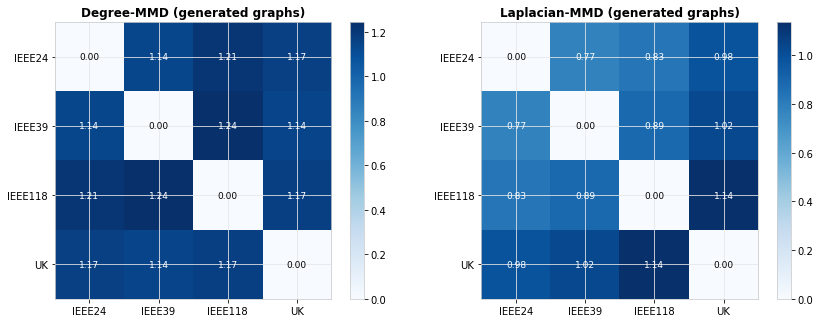

,IEEE24,IEEE39,IEEE118,UK
IEEE24,0.000,0.773,0.826,0.981
IEEE39,0.773,0.000,0.887,1.025
IEEE118,0.826,0.887,0.000,1.136
UK,0.981,1.025,1.136,0.000


In [8]:
import itertools
# subsample for speed (MMD is over distributions; 120 graphs/grid is plenty)
rng = np.random.default_rng(0)
sub = {g: [train[g][i] for i in rng.choice(len(train[g]), size=120, replace=False)] for g in GRIDS}
Dd = np.zeros((4, 4)); Dl = np.zeros((4, 4))
for i, j in itertools.combinations(range(4), 2):
    md_ij, ml_ij = evaluate_mmd(sub[GRIDS[i]], sub[GRIDS[j]])
    Dd[i, j] = Dd[j, i] = md_ij; Dl[i, j] = Dl[j, i] = ml_ij

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, D, title in [(axes[0], Dd, "Degree-MMD"), (axes[1], Dl, "Laplacian-MMD")]:
    im = ax.imshow(D, cmap="Blues")
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(GRIDS); ax.set_yticklabels(GRIDS)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{D[i,j]:.2f}", ha="center", va="center",
                    color="white" if D[i, j] > D.max() * 0.6 else "black", fontsize=9)
    ax.set_title(f"{title} (generated graphs)")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()
pd.DataFrame(Dl, index=GRIDS, columns=GRIDS).round(3)

**Findings & implication.** On the *generated* distributions the same structure
holds as in the raw data: **UK is the most distant grid** from the others and the
IEEE grids are closer to one another. *Implication:* the topological distance the
g-score relies on is a genuine property of the data (it survives contingency
perturbation), so distance-aware generalization claims — and the expectation that
UK is the hardest held-out grid — are well grounded.

## Step 8 — Conclusions & implications for next steps

**What the generated-data EDA established (findings):**
1. **Generation is reliable and balanced** — 800 samples/grid, full contract,
   DC baseline present, no missing targets.
2. **Topology is genuinely varied** — a controlled mix of N-0/N-1/N-2 outages;
   edge counts change sample to sample (`edge_index` carries information).
3. **Targets are scale-heterogeneous** — V is tightly bounded while P/Q/θ vary
   widely and per grid, empirically justifying per-quantity + range-normalized
   NRMSE.
4. **DC is a fair-but-beatable baseline** — exact on P/Q (carried injections)
   but blind to **voltage** (flat 1.0 pu assumption), so the AC−DC gap is
   concentrated in V (and θ) and is grid-dependent.
5. **Masking is correct with no leakage** — NaN pattern in `x` matches bus-type
   physics; targets `y` are fully observed.
6. **Structural distance survives generation** — UK remains the MMD outlier on
   the sampled graph distributions.

**Implications / next steps:**
- **Trust the accuracy numbers** — the leakage check clears the way to interpret
  transfer results.
- **Always read per-quantity errors** — never the aggregate alone, given the V
  range effect confirmed here.
- **Consider provenance/coverage refinements** — this run used *random* N-k; a
  next iteration could use harvested cascade triggers and stratify demand
  snapshots across seasons for more operationally-weighted coverage.
- **Log reject rates** — record islanding/non-convergence rejections per grid in
  provenance so sampling bias can be audited directly (a small pipeline
  improvement surfaced by this EDA).